In [3]:
import pandas as pd
df = pd.read_csv('../data/train.csv')

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   id             159571 non-null  str  
 1   comment_text   159571 non-null  str  
 2   toxic          159571 non-null  int64
 3   severe_toxic   159571 non-null  int64
 4   obscene        159571 non-null  int64
 5   threat         159571 non-null  int64
 6   insult         159571 non-null  int64
 7   identity_hate  159571 non-null  int64
dtypes: int64(6), str(2)
memory usage: 9.7 MB


In [4]:
#remove label columns apart from toxic
df = df.drop( columns = ['severe_toxic','obscene','threat','insult','identity_hate'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   id            159571 non-null  str  
 1   comment_text  159571 non-null  str  
 2   toxic         159571 non-null  int64
dtypes: int64(1), str(2)
memory usage: 3.7 MB


In [6]:
#basic text cleaning

import re
import contractions

def clean_text(text):

    text = text.lower()                        #lowercase
    text = contractions.fix(text)              #contraction expansion
    text = re.sub(r'[^a-z]', ' ', text)        #replace non-alphabet with space
    text = re.sub(r'\s+', ' ', text).strip()   #remove extra space

    return text

#apply to new column
df['clean_text'] = df['comment_text'].apply(clean_text)

#remove empty rowes after cleaning
df = df[df['clean_text'] != ""]

In [7]:
#drop duplications

df = df.drop_duplicates( subset = ['clean_text'] )

In [8]:
#info about data after cleaning
df.info()

<class 'pandas.DataFrame'>
Index: 158237 entries, 0 to 159570
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   id            158237 non-null  str  
 1   comment_text  158237 non-null  str  
 2   toxic         158237 non-null  int64
 3   clean_text    158237 non-null  str  
dtypes: int64(1), str(3)
memory usage: 6.0 MB


In [9]:
#label distribution
df['toxic'].value_counts()

toxic
0    143080
1     15157
Name: count, dtype: int64

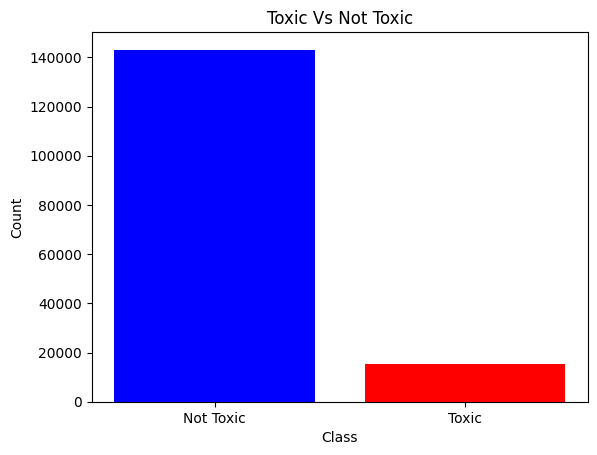

In [11]:
#bar graph for label distribution

import matplotlib.pyplot as plt

plt.bar(['Not Toxic','Toxic'] , df['toxic'].value_counts(), color = ['blue', 'red'])
plt.title('Toxic Vs Not Toxic')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [ ]:
#generate clean data set file
# df.to_csv('clean_data.csv', index = False )

In [13]:
df

,id,comment_text,toxic,clean_text
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,explanation why the edits made under my userna...
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,d aww he matches this background colour i am s...
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,hey man i am really not trying to edit war it ...
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,more i cannot make any real suggestions on imp...
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,you sir are my hero any chance you remember wh...
...,...,...,...,...
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,and for the second time of asking when your vi...
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,you should be ashamed of yourself that is a ho...
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,spitzer umm there is no actual article for pro...
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,and it looks like it was actually you who put ...


In [ ]:
oangsa_features = ["Word TF-IDF", "Character Count", "Word Count", "Repeated Characters Score", "Average Word Length"]

In [ ]:
# implement Word TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=10000, min_df=2, max_df=0.9)  # Limit to top 1000 features
tfidf_features = tfidf_vectorizer.fit_transform(df["clean_text"])

# print(tfidf_vectorizer.get_feature_names_out())

['able' 'about' 'above' 'absolutely' 'abuse' 'accept' 'accepted' 'access'
 'according' 'account' 'accurate' 'act' 'action' 'actions' 'actual'
 'actually' 'add' 'added' 'adding' 'addition' 'address' 'admin'
 'administrator' 'administrators' 'admins' 'advice' 'afd' 'after' 'again'
 'against' 'ago' 'agree' 'al' 'album' 'align' 'all' 'allow' 'allowed'
 'almost' 'alone' 'along' 'already' 'also' 'although' 'always' 'am'
 'america' 'american' 'among' 'an' 'and' 'anonymous' 'another' 'answer'
 'anti' 'any' 'anyone' 'anything' 'anyway' 'apparently' 'appear' 'appears'
 'appreciate' 'appropriate' 'april' 'archive' 'are' 'area' 'argument'
 'arguments' 'around' 'article' 'articles' 'as' 'ask' 'asked' 'asking'
 'ass' 'asshole' 'assume' 'at' 'attack' 'attacks' 'attempt' 'attention'
 'august' 'author' 'automatically' 'available' 'avoid' 'aware' 'away'
 'back' 'background' 'bad' 'balls' 'ban' 'band' 'banned' 'based' 'be'
 'because' 'become' 'been' 'before' 'behavior' 'being' 'believe' 'below'
 'best' '

In [17]:
def repeated_characters_score(text):
    score = 0
    for char in set(text):
        count = text.count(char)
        if count > 1:
            score += count - 1
    return score

In [18]:
#implement the rest of the features

# oangsa_features = ["Word TF-IDF", "Character Count", "Word Count", "Repeated Characters Score", "Average Word Length"]


character_count = df['clean_text'].apply(len)
word_count = df['clean_text'].apply(lambda x: len(x.split()))
repeated_characters = df['clean_text'].apply(repeated_characters_score)
average_word_length = df['clean_text'].apply(lambda x: sum(len(word) for word in x.split()) / len(x.split()) if len(x.split()) > 0 else 0)

# put features in df

df['Character Count'] = character_count
df['Word Count'] = word_count
df['Repeated Characters Score'] = repeated_characters
df['Average Word Length'] = average_word_length

df

,id,comment_text,toxic,clean_text,Word TF-IDF,Character Count,Word Count,Repeated Characters Score,Average Word Length
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,explanation why the edits made under my userna...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",251,46,227,4.478261
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,d aww he matches this background colour i am s...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",89,16,68,4.625000
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,hey man i am really not trying to edit war it ...,"[0.0, 0.11733212153828124, 0.0, 0.0, 0.0, 0.0,...",231,44,207,4.272727
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,more i cannot make any real suggestions on imp...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",603,115,579,4.252174
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,you sir are my hero any chance you remember wh...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",64,14,46,3.642857
...,...,...,...,...,...,...,...,...,...
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,and for the second time of asking when your vi...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",273,45,250,5.088889
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,you should be ashamed of yourself that is a ho...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",82,17,62,3.882353
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,spitzer umm there is no actual article for pro...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",75,12,57,5.333333
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,and it looks like it was actually you who put ...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",115,25,95,3.640000
